# Read and plot one ATST readout

All conditions in `Fig_4g_OD600`; labels, colours and units follow the ATST data.


In [1]:
from IPython.display import display
from ATST import read_atst

study = read_atst("atst_zou_2022/atst_zou_2022.atst.txt", multi_readouts=True)
readout_id = "Fig_4g_OD600"
readout = study.readouts[readout_id]


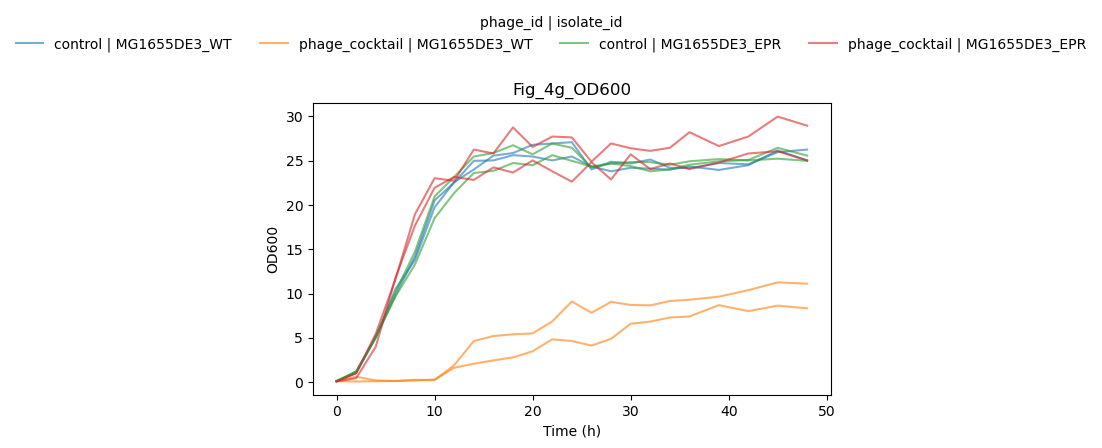

In [2]:
readout.plot(group_by=["phage_id", "isolate_id"])


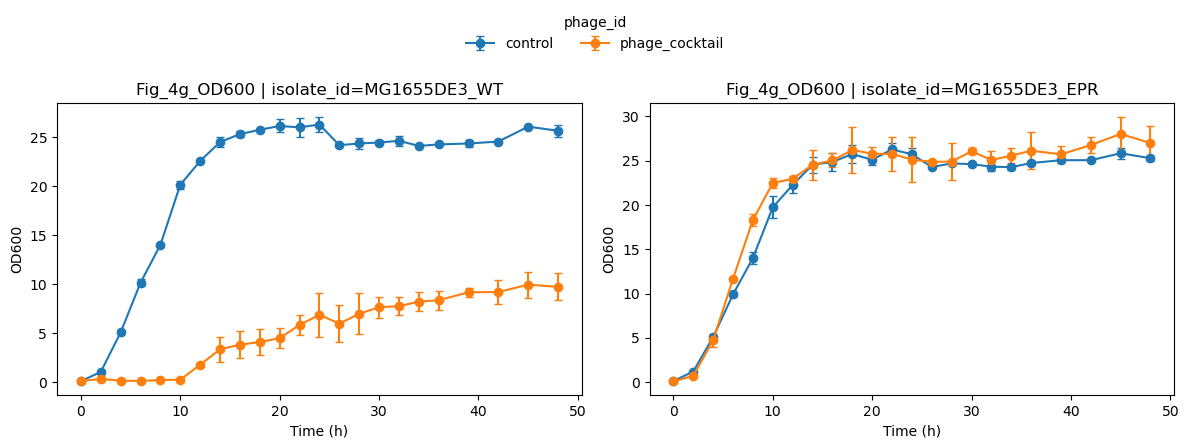

In [3]:
readout.plot(group_by=["phage_id"], facet_by=["isolate_id"], summary="median_minmax")


In [4]:
for name, block in [
    ("FILE_INFO", study.file_info),
    ("STUDY", study.study),
    ("METADATA", readout.metadata),
    ("ASSAY", readout.assay),
]:
    print(name)
    display(block.data)
print("LAYOUT")
display(readout.layout.data)
for name, table in study.entities.tables.items():
    print(name)
    display(table.data)


FILE_INFO


{'file_name': 'atst_zou_2022.atst.txt',
 'format': 'ATST',
 'format_version': '0.1',
 'created_on': '2026-10-08',
 'field_delimiter': 'TAB',
 'encoding': 'UTF-8'}

STUDY


{'title': 'Systematic strategies for developing phage resistant Escherichia coli strains',
 'study_id': 'doi:10.1038/s41467-022-31934-9',
 'authors': 'Xuan Zou et al.',
 'publication_doi': '10.1038/s41467-022-31934-9',
 'publication_date': '2022',
 'description': 'Source-data OD600 growth and fermentation series, plus separate 445-nm absorbance series for DAAO assay.'}

METADATA


...

,ISOLATE_ID,species,strain,modification
0,MG1655_WT,Escherichia coli,MG1655,parental
1,MG1655_pSK_empty,Escherichia coli,MG1655,pSK+ empty vector PT-
2,MG1655_pWHU3640,Escherichia coli,MG1655,pWHU3640 expressing SspBCDE PT+
3,MG1655_PT,Escherichia coli,MG1655,integrated SspBCDE PT strain
4,MG1655_EPR,Escherichia coli,MG1655,engineered phage resistant
5,MG1655DE3_WT,Escherichia coli,MG1655(DE3),parental
6,MG1655DE3_EPR,Escherichia coli,MG1655(DE3),engineered phage resistant
7,W3110_WT,Escherichia coli,W3110,parental
8,W3110_EPR,Escherichia coli,W3110,engineered phage resistant


PHAGES


,PHAGE_ID,name,kind,components
0,T1,T1,single,
1,JMPW2,JMPW2,single,
2,T4,T4,single,
3,T5,T5,single,
4,T7,T7,single,
5,EEP,EEP,single,
6,lambda,lambda,single,
7,phage_cocktail,T1/JMPW2/T4/T5/T7/EEP/lambda mixture,mixture,T1;JMPW2;T4;T5;T7;EEP;lambda


MEDIA


,MEDIUM_ID,name
0,LB,Luria-Bertani medium
1,fed_batch,Fed-batch fermentation medium


In [5]:
display(readout.summarize(group_by=["isolate_id", "phage_id"]))


,isolate_id,phage_id,Time,n,mean,sd,median,min,max
0,MG1655DE3_WT,,0.0,2,0.1100,0.011314,0.1100,0.102,0.118
1,MG1655DE3_WT,,2.0,2,1.0500,0.014142,1.0500,1.040,1.060
2,MG1655DE3_WT,,4.0,2,5.0800,0.056569,5.0800,5.040,5.120
3,MG1655DE3_WT,,6.0,2,10.1500,0.494975,10.1500,9.800,10.500
4,MG1655DE3_WT,,8.0,2,14.0100,0.268701,14.0100,13.820,14.200
...,...,...,...,...,...,...,...,...,...
87,MG1655DE3_EPR,phage_cocktail,36.0,2,26.1415,2.945100,26.1415,24.059,28.224
88,MG1655DE3_EPR,phage_cocktail,39.0,2,25.7250,1.316633,25.7250,24.794,26.656
89,MG1655DE3_EPR,phage_cocktail,42.0,2,26.7785,1.351281,26.7785,25.823,27.734
90,MG1655DE3_EPR,phage_cocktail,45.0,2,28.0280,2.771859,28.0280,26.068,29.988
